## Block 1 — Mount Drive & copy images to local Colab storage (fast I/O)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# copy images folder from Drive to Colab local disk (adjust source path if different)
!cp -r /content/drive/MyDrive/mini_proj_data/images /content/images


Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/mini_proj_data/images': No such file or directory


## Block 2 — Load CSV, prepare metadata, labels and image paths; create train/val/test splits

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
import os

# Load metadata CSV
df = pd.read_csv('/content/drive/MyDrive/mini_proj_data/processed_data.csv')

# Keep only useful cols
df = df[['image_path','clean_path','age','sex','localization','dx','dx_type']].copy()

# --- Handle missing values safely ---
df['age'] = pd.to_numeric(df['age'], errors='coerce')   # force non-numeric → NaN
df['age'] = df['age'].fillna(df['age'].median())        # fill NaN with median

# Clean up sex values
df['sex'] = df['sex'].str.lower().replace({'nan': np.nan, 'unknown': np.nan, '': np.nan})
df['sex'] = df['sex'].map({'male':0,'female':1})
df['sex'] = df['sex'].fillna(-1).astype('float32')      # -1 = unknown

# Drop rows with missing paths or dx
df = df.dropna(subset=['clean_path','dx'])

# One-hot encode categorical vars (localization, dx_type)
for col in ['localization','dx_type']:
    df[col] = df[col].fillna('unknown')
df = pd.get_dummies(df, columns=['localization','dx_type'], drop_first=False)

# Scale age safely
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']]).astype('float32')

# Collect metadata features
feature_cols = ['age_scaled','sex'] + [c for c in df.columns if c.startswith('localization_') or c.startswith('dx_type_')]
X_meta_all = df[feature_cols].values.astype('float32')

# ----- Labels: DX (7 classes) -----
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df['dx'])   # convert dx to integers
class_names = label_encoder.classes_
print("DX classes:", class_names)

# One-hot encode labels
num_classes = len(class_names)
y_all_cat = to_categorical(y_all, num_classes=num_classes).astype('float32')

# Replace Drive paths with local paths
def map_to_local(path):
    return str(path).replace('/content/drive/MyDrive/mini_proj_data/images', '/content/images')

image_paths_all = df['clean_path'].astype(str).apply(map_to_local).values

# Drop missing images
missing = [p for p in image_paths_all if not os.path.exists(p)]
if len(missing) > 0:
    print(f"⚠️ {len(missing)} missing images will be dropped (showing first 5):", missing[:5])
    keep_mask = np.array([p not in missing for p in image_paths_all])
    image_paths_all = image_paths_all[keep_mask]
    X_meta_all = X_meta_all[keep_mask]
    y_all_cat = y_all_cat[keep_mask]
    y_all = y_all[keep_mask]   # keep integer labels in sync

# Train/val/test split (stratified by dx)
train_idx, temp_idx = train_test_split(np.arange(len(y_all)), test_size=0.3, stratify=y_all, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

train_paths, val_paths, test_paths = image_paths_all[train_idx], image_paths_all[val_idx], image_paths_all[test_idx]
train_meta,  val_meta,  test_meta  = X_meta_all[train_idx], X_meta_all[val_idx], X_meta_all[test_idx]
train_labels, val_labels, test_labels = y_all_cat[train_idx], y_all_cat[val_idx], y_all_cat[test_idx]

# Loss function → categorical crossentropy
chosen_loss = 'categorical_crossentropy'

print(f"✅ Dataset sizes: train={len(train_paths)}, val={len(val_paths)}, test={len(test_paths)}, num_classes={num_classes}")


DX classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
✅ Dataset sizes: train=8236, val=1765, test=1766, num_classes=7


## Block 3 — Build tf.data pipeline (with normalization, clipping, caching, prefetching)

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return tf.clip_by_value(image, 0.0, 1.0)

def preprocess_meta(meta):
    return tf.clip_by_value(meta, -5.0, 5.0)

# Create datasets
ds_train_imgs = tf.data.Dataset.from_tensor_slices(train_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_val_imgs   = tf.data.Dataset.from_tensor_slices(val_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_test_imgs  = tf.data.Dataset.from_tensor_slices(test_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

ds_train_meta = tf.data.Dataset.from_tensor_slices(train_meta).map(preprocess_meta)
ds_val_meta   = tf.data.Dataset.from_tensor_slices(val_meta).map(preprocess_meta)
ds_test_meta  = tf.data.Dataset.from_tensor_slices(test_meta).map(preprocess_meta)

ds_train_lab = tf.data.Dataset.from_tensor_slices(train_labels)
ds_val_lab   = tf.data.Dataset.from_tensor_slices(val_labels)
ds_test_lab  = tf.data.Dataset.from_tensor_slices(test_labels)

# Zip into ((image, meta), label)
train_ds = tf.data.Dataset.zip(((ds_train_imgs, ds_train_meta), ds_train_lab))
val_ds   = tf.data.Dataset.zip(((ds_val_imgs, ds_val_meta), ds_val_lab))
test_ds  = tf.data.Dataset.zip(((ds_test_imgs, ds_test_meta), ds_test_lab))

# Final performance tweaks
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Sanity check a batch
for (img_batch, meta_batch), lab_batch in train_ds.take(1):
    print("🖼 img:", img_batch.shape)
    print("📊 meta:", meta_batch.shape)
    print("🏷 labels:", lab_batch.shape)

🖼 img: (32, 224, 224, 3)
📊 meta: (32, 21)
🏷 labels: (32, 7)


## Block 4 — Build the dual-CNN + metadata fusion model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, ResNet50

# Backbone 1 (EfficientNetB0)
base_model_1 = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
base_model_1.trainable = False
cnn_branch_1 = models.Sequential([base_model_1, layers.GlobalAveragePooling2D(), layers.Dropout(0.3)], name="cnn_branch_1")

# Backbone 2 (ResNet50)
base_model_2 = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE,3))
base_model_2.trainable = False
cnn_branch_2 = models.Sequential([base_model_2, layers.GlobalAveragePooling2D(), layers.Dropout(0.3)], name="cnn_branch_2")

# Metadata branch
metadata_input = layers.Input(shape=(train_meta.shape[1],), name="metadata_input")
metadata_branch = models.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu")
], name="metadata_branch")

# Image input
image_input = layers.Input(shape=(*IMG_SIZE,3), name="image_input")
features_1 = cnn_branch_1(image_input)
features_2 = cnn_branch_2(image_input)
features_meta = metadata_branch(metadata_input)

# Fusion
fusion = layers.Concatenate()([features_1, features_2, features_meta])
x = layers.Dense(128, activation="relu")(fusion)
x = layers.Dropout(0.4)(x)

# Multi-class output
output = layers.Dense(num_classes, activation="softmax", name="output")(x)
loss_fn = chosen_loss
metrics = ["accuracy"]

model = models.Model(inputs=[image_input, metadata_input], outputs=output)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch_1        │ (None, 1280)      │  4,049,571 │ image_input[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch_2        │ (None, 2048)      │ 23,587,712 │ image_input[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_branch     │ (None, 32)        │      3,488 │ metadata_input[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3360)      │          0 │ cnn_branch_1[0][… │
│ (Concatenate)       │                   │            │ cnn_branch_2[0][… │
│                     │                   │            │ metadata_branch[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    430,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,071,882 (107.09 MB)

 Trainable params: 434,599 (1.66 MB)

 Non-trainable params: 27,637,283 (105.43 MB)

## Block 5 — Compile, smoke-test, train (epochs=15), evaluate, predict, save

Running a smoke-test (1 epoch)...
258/258 ━━━━━━━━━━━━━━━━━━━━ 1619s 6s/step - accuracy: 0.5012 - loss: 1.6184 - val_accuracy: 0.5700 - val_loss: 1.4004
Smoke-test passed. Proceeding to full training for 15 epochs.
Epoch 1/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.5835 - loss: 1.3759 - val_accuracy: 0.6102 - val_loss: 1.1630 - learning_rate: 1.0000e-04
Epoch 2/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 45s 161ms/step - accuracy: 0.5971 - loss: 1.2120 - val_accuracy: 0.6119 - val_loss: 1.0907 - learning_rate: 1.0000e-04
Epoch 3/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.6098 - loss: 1.1216 - val_accuracy: 0.6113 - val_loss: 1.0793 - learning_rate: 1.0000e-04
Epoch 4/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.6119 - loss: 1.1062 - val_accuracy: 0.6176 - val_loss: 1.0606 - learning_rate: 1.0000e-04
Epoch 5/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.6179 - loss: 1.0771 - val_accuracy: 0.6130 - val_loss: 1.0527 - learning_rate: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


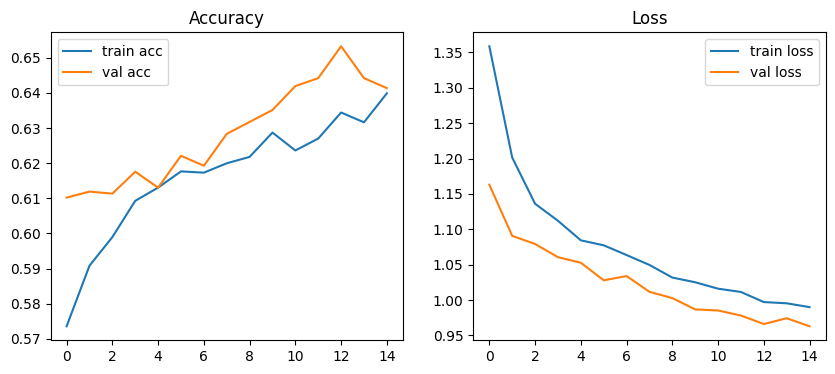

Model saved to dual_cnn_metadata_model.h5


In [ ]:
from tensorflow.keras import optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Use gradient clipping to avoid exploding gradients (helps prevent NaNs)
opt = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=opt, loss=loss_fn, metrics=metrics)

# Custom callback to stop training if NaN/Inf appears
class TerminateOnNaN(callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        if logs is not None:
            loss = logs.get("loss")
            if loss is not None and (tf.math.is_nan(loss) or tf.math.is_inf(loss)):
                print(f"\nNaN or Inf detected at batch {batch} - stopping training.")
                self.model.stop_training = True

# Short smoke-test (1 epoch) to confirm stability
print("Running a smoke-test (1 epoch)...")
smoke = model.fit(train_ds, validation_data=val_ds, epochs=1, callbacks=[TerminateOnNaN()], verbose=1)

# If smoke-test produced NaNs it will have stopped. Check quickly:
if any([np.isnan(x) for x in smoke.history.get('loss', [])]):
    raise RuntimeError("NaN appeared during smoke-test. Do not continue; inspect inputs/labels.")
else:
    print("Smoke-test passed. Proceeding to full training for 15 epochs.")

# Callbacks for full training
cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6),
    TerminateOnNaN()
]

# Full training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  # reduced for speed
    callbacks=cb,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(test_ds)
print("Test results (loss + metrics):", results)

# Predictions & reports
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Collect true labels from test set (argmax on one-hot labels)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds], axis=0)

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

# Plots: accuracy & loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train acc')
plt.plot(history.history.get('val_accuracy', []), label='val acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train loss')
plt.plot(history.history.get('val_loss', []), label='val loss')
plt.legend(); plt.title('Loss')
plt.show()

# Save model
model.save("dual_cnn_metadata_model.h5")
print("Model saved to dual_cnn_metadata_model.h5")


## Finetuning block

In [ ]:
import tensorflow as tf
from tensorflow.keras import optimizers, callbacks

# 0) Save a backup of current weights (so you can revert easily)
model.save("model_before_finetune.h5")
print("Saved backup: model_before_finetune.h5")

# 1) Finetune settings
UNFREEZE_LAST_N = 30      # safe starting value (smaller = safer). Try 10-50.
FINETUNE_LR = 1e-5
FINETUNE_EPOCHS = 10
CLIPNORM = 1.0

# 2) Helper: freeze BatchNorm layers
def set_bn_trainable(model, trainable=False):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = trainable

# 3) Unfreeze last UNFREEZE_LAST_N layers of each backbone
for bm in [base_model_1, base_model_2]:
    bm.trainable = True
    if UNFREEZE_LAST_N > 0:
        for layer in bm.layers[:-UNFREEZE_LAST_N]:
            layer.trainable = False

# 4) Keep BatchNorm layers frozen
set_bn_trainable(base_model_1, trainable=False)
set_bn_trainable(base_model_2, trainable=False)

# 5) Recompile
opt_ft = optimizers.Adam(learning_rate=FINETUNE_LR, clipnorm=CLIPNORM)
model.compile(optimizer=opt_ft, loss=loss_fn, metrics=metrics)
print("Model recompiled for finetuning. Trainable params:",
      sum([tf.keras.backend.count_params(p) for p in model.trainable_weights]))

# 6) Callbacks
ckpt = callbacks.ModelCheckpoint("best_finetuned_model.h5", monitor="val_loss", save_best_only=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1)
early = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)

class CheckNaN(callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        if logs is not None and 'loss' in logs:
            if tf.math.is_nan(logs['loss']):
                print("NaN detected at batch", batch, "- stopping finetune")
                self.model.stop_training = True

# 7) Run finetuning
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=[ckpt, reduce_lr, early, CheckNaN()],
    verbose=1
)

# 8) Load best checkpoint
try:
    model.load_weights("best_finetuned_model.h5")
    print("Loaded best_finetuned_model.h5")
except Exception as e:
    print("No checkpoint loaded:", e)

# 9) Evaluate and save
print("Evaluating finetuned model on test set:")
print(model.evaluate(test_ds))
model.save("model_finetuned.h5")
print("Saved finetuned model: model_finetuned.h5")


Saved backup: model_before_finetune.h5
Model recompiled for finetuning. Trainable params: 16346631
Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6446 - loss: 0.9749
Epoch 1: val_loss improved from inf to 0.95566, saving model to best_finetuned_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 132s 339ms/step - accuracy: 0.6446 - loss: 0.9749 - val_accuracy: 0.6538 - val_loss: 0.9557 - learning_rate: 1.0000e-05
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6386 - loss: 0.9752
Epoch 2: val_loss improved from 0.95566 to 0.95055, saving model to best_finetuned_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 52s 192ms/step - accuracy: 0.6386 - loss: 0.9752 - val_accuracy: 0.6561 - val_loss: 0.9505 - learning_rate: 1.0000e-05
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6465 - loss: 0.9707
Epoch 3: val_loss did not improve from 0.95055
258/258 ━━━━━━━━━━━━━━━━━━━━ 54s 181ms/step - accuracy: 0.6465 - loss: 0.9707 - val_accuracy: 0.6499 - val_loss: 0.9624 - learning_rate: 1.0000e-05
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6499 - loss: 0.9587
Epoch 4: val_loss improved from 0.95055 to 0.94052, saving model to best_finetuned_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 52s 191ms/step - accuracy: 0.6499 - loss: 0.9588 - val_accuracy: 0.6561 - val_loss: 0.9405 - learning_rate: 1.0000e-05
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6533 - loss: 0.9546
Epoch 5: val_loss did not improve from 0.94052
258/258 ━━━━━━━━━━━━━━━━━━━━ 50s 182ms/step - accuracy: 0.6532 - loss: 0.9547 - val_accuracy: 0.6578 - val_loss: 0.9468 - learning_rate: 1.0000e-05
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6589 - loss: 0.9463
Epoch 6: val_loss improved from 0.94052 to 0.92720, saving model to best_finetuned_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 51s 188ms/step - accuracy: 0.6588 - loss: 0.9464 - val_accuracy: 0.6725 - val_loss: 0.9272 - learning_rate: 1.0000e-05
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6499 - loss: 0.9507
Epoch 7: val_loss did not improve from 0.92720
258/258 ━━━━━━━━━━━━━━━━━━━━ 50s 183ms/step - accuracy: 0.6499 - loss: 0.9508 - val_accuracy: 0.6686 - val_loss: 0.9274 - learning_rate: 1.0000e-05
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6540 - loss: 0.9421
Epoch 8: val_loss improved from 0.92720 to 0.91965, saving model to best_finetuned_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 57s 210ms/step - accuracy: 0.6540 - loss: 0.9421 - val_accuracy: 0.6708 - val_loss: 0.9197 - learning_rate: 1.0000e-05
Epoch 9/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6530 - loss: 0.9373
Epoch 9: val_loss did not improve from 0.91965
258/258 ━━━━━━━━━━━━━━━━━━━━ 50s 183ms/step - accuracy: 0.6530 - loss: 0.9373 - val_accuracy: 0.6595 - val_loss: 0.9391 - learning_rate: 1.0000e-05
Epoch 10/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6633 - loss: 0.9330
Epoch 10: val_loss did not improve from 0.91965
258/258 ━━━━━━━━━━━━━━━━━━━━ 49s 181ms/step - accuracy: 0.6633 - loss: 0.9330 - val_accuracy: 0.6584 - val_loss: 0.9434 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 8.
Loaded best_finetuned_model.h5
Evaluating finetuned model on test set:
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - accuracy: 0.6717 - loss: 0.9158


[0.9036749601364136, 0.672706663608551]
Saved finetuned model: model_finetuned.h5


## Plot training curves & evaluate finetuned model

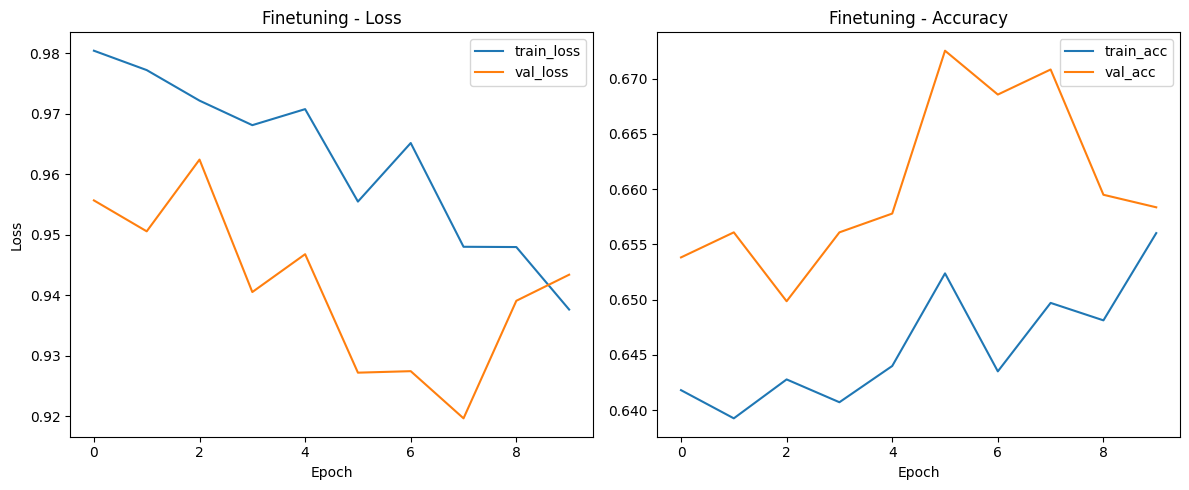


🔍 Evaluating on test set...
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.6717 - loss: 0.9158
Test loss: 0.9036749601364136
Test accuracy: 0.672706663608551
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 299ms/step


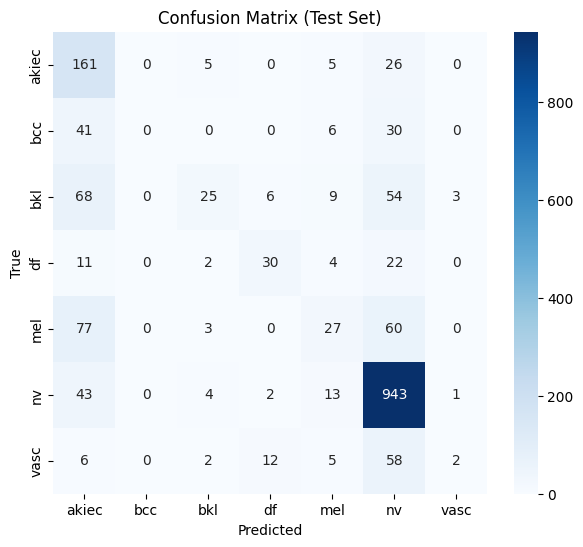


Classification Report:
              precision    recall  f1-score   support

       akiec     0.3956    0.8173    0.5331       197
         bcc     0.0000    0.0000    0.0000        77
         bkl     0.6098    0.1515    0.2427       165
          df     0.6000    0.4348    0.5042        69
         mel     0.3913    0.1617    0.2288       167
          nv     0.7904    0.9374    0.8577      1006
        vasc     0.3333    0.0235    0.0440        85

    accuracy                         0.6727      1766
   macro avg     0.4458    0.3609    0.3444      1766
weighted avg     0.6279    0.6727    0.6142      1766



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1) Plot training curves
def plot_history(history, title="Training history"):
    hist = history.history
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    if 'accuracy' in hist:
        plt.plot(hist['accuracy'], label='train_acc')
        plt.plot(hist['val_accuracy'], label='val_acc')
        plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_ft, title="Finetuning")

# 2) Evaluate on test set
print("\n🔍 Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 3) Predictions & confusion matrix
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# 4) Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


## 📊 Dual CNN + Metadata Fusion Model — Results (multi-class: `dx`, 7 classes)

### ✅ Key test metrics
- Test accuracy: **0.6727**
- Test support: **1766**
- Macro F1 (test): **0.3444**
- Weighted F1 (test): **0.6142**

### Per-class (precision / recall / f1 / support)
- akiec: 0.3956 / 0.8173 / 0.5331 (support=197)
- bcc:   0.0000 / 0.0000 / 0.0000 (support=77)
- bkl:   0.6098 / 0.1515 / 0.2427 (support=165)
- df:    0.6000 / 0.4348 / 0.5042 (support=69)
- mel:   0.3913 / 0.1617 / 0.2288 (support=167)
- nv:    0.7904 / 0.9374 / 0.8577 (support=1006)
- vasc:  0.3333 / 0.0235 / 0.0440 (support=85)
